_This notebook was developed by [Keneth Garcia](https://www.linkedin.com/in/keneth-garcia-a6305b1b9/). Source and license info are on [GitHub](https://github.com/KenethGarcia/SieveComP)._

# Polygon validation

**_SieveComP_** have the option to use polygons to mask the data. This notebook shows how to validate if the polygons inside `RSNC` and `volcanological_observatories` are valid. The reason for this is that not valid polygons can cause problems when trying to mask the data. For example, if a polygon is not valid, it can cause the program to crash or produce incorrect results. Therefore, it is important to validate the polygons before using them.

Let's start by importing the necessary libraries and loading the data:

In [32]:
import os
import matplotlib.pyplot as plt
from shapely.constructive import make_valid
from shapely.plotting import plot_polygon, plot_points
from shapely.geometry import Polygon, Point, MultiPolygon

# List of paths where the files are located
rsnc_path = "../../examples/data/polygons/SGC/RSNC"
volcanic_path = "../../examples/data/polygons/SGC/volcanological_observatories"

# List all files in the paths
rsnc_files = [f for f in os.listdir(rsnc_path) if f.endswith((".txt", ".geojson")) and os.path.isfile(os.path.join(rsnc_path, f))]
volcanic_files = [f for f in os.listdir(volcanic_path) if f.endswith((".txt", ".geojson")) and os.path.isfile(os.path.join(volcanic_path, f))]
print("RSNC files:", rsnc_files)
print("Volcanic files:", volcanic_files)

RSNC files: ['zona4.txt', 'arealocal.txt', 'ptogaitan.txt', 'cesar.txt', 'VMM.txt', 'NLL.txt', 'zona5.txt', 'ptogaitan.geojson', 'zona2.txt', 'zona3.txt', 'nazca.txt', 'zona1.txt', 'caribe.txt', 'carma.txt']
Volcanic files: ['obspopvnh.txt', 'obspas7.txt', 'obspas5.txt', 'obspas1.txt', 'obspas3.txt', 'obspop.txt', 'obspas9.txt', 'obspas2.txt', 'obspas8.txt', 'obspas6.txt', 'obspas4.txt', 'obsman.txt']


With all the files listed, we can now read the files and validate the polygons. It is important to state that the txt files are in format BNA, which means that the first column is the longitude and the second column is the latitude. Moreover, the first row contains the metadata of the polygon, which is not used in this case. Therefore, we will skip the first row when reading the files. The following code reads the files and stores the coordinates in a dictionary, where the key is the file name and the value is a list of tuples with the coordinates.

In [14]:
# Read the model file for both regular and volcanic zones
def model_reader(
        path,
        files_name
):
    """
    Read the model file for both regular and volcanic zones.

    Parameters
    ----------
    path: str
        Path to the folder where the files are located.
    files_name: list
        List of files to read. Example: ['file1.txt', 'file2.txt']
    """
    polygon_dict = {}
    for file in files_name:
        file_path = rf"{path}/{file}"
        # First case: The polygon is in txt format
        if file.endswith('.txt'):
            with open(file_path, 'r') as f:
                lines = f.readlines()
                # Skip the first line and read the coordinates
                coords = [tuple(map(float, line.strip().split(','))) for line in lines[1:]]
                polygon_dict[file] = coords
        elif file.endswith('.geojson'):
            import json
            with open(file_path, 'r') as f:
                data = json.load(f)
                # Read the coordinates from the geojson file
                coords = data['features'][0]['geometry']['coordinates'][0]
                polygon_dict[file] = coords

    return polygon_dict

In [15]:
# Read model files
zone_data = model_reader(rsnc_path, files_name=rsnc_files)
volcanic_data = model_reader(volcanic_path, files_name=volcanic_files)

# Using shapely to validate the polygons

**_SieveComP_** uses the `shapely` library to validate the polygons. The `shapely` library provides a method called `is_valid` that checks if a polygon is valid. In this context, a polygon is valid if it does not have any self-intersections or other geometric issues. If a polygon is not valid, we can use the `buffer(0)` method to create a buffer around the polygon, which can help to fix some of the issues. If the polygon is still not valid after buffering, we can use the `make_valid` method to create a valid polygon from the original one.

Let's start by loading all the polygons using shapely to a dictionary, and then plot them to visualize the polygons.

Text(0, 0.5, 'Latitude')

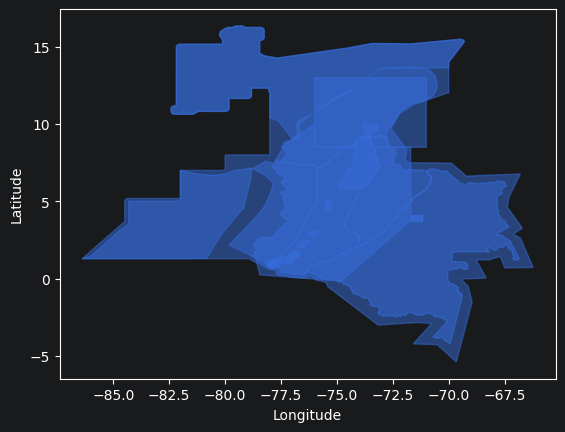

In [16]:
# Load all the polygons using shapely to a dictionary
shapely_zone_data = {file: Polygon(coords) for file, coords in zone_data.items()}
shapely_volcanic_data = {file: Polygon(coords) for file, coords in volcanic_data.items()}

# Plot the polygons to visualize them
fig, ax = plt.subplots()
for file, polygon in shapely_zone_data.items():
    plot_polygon(polygon, ax=ax, add_points=False, alpha=0.5)
for file, polygon in shapely_volcanic_data.items():
    plot_polygon(polygon, ax=ax, add_points=False, alpha=0.5)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

Now let's validate the polygons using the `is_valid` method. We will check if the polygons are valid and print the results.

In [19]:
# Validate the polygons using the is_valid method
for file, polygon in shapely_zone_data.items():
    is_valid = polygon.is_valid
    if not is_valid:
        print(f"The polygon in {file} is not valid.")
    else:
        print(f"The polygon in {file} is valid.")
for file, polygon in shapely_volcanic_data.items():
    is_valid = polygon.is_valid
    if not is_valid:
        print(f"The polygon in {file} is not valid.")
    else:
        print(f"The polygon in {file} is valid.")

The polygon in zona4.txt is valid.
The polygon in arealocal.txt is valid.
The polygon in ptogaitan.txt is valid.
The polygon in cesar.txt is valid.
The polygon in VMM.txt is valid.
The polygon in NLL.txt is valid.
The polygon in zona5.txt is valid.
The polygon in ptogaitan.geojson is valid.
The polygon in zona2.txt is valid.
The polygon in zona3.txt is valid.
The polygon in nazca.txt is valid.
The polygon in zona1.txt is valid.
The polygon in caribe.txt is valid.
The polygon in carma.txt is valid.
The polygon in obspopvnh.txt is valid.
The polygon in obspas7.txt is valid.
The polygon in obspas5.txt is valid.
The polygon in obspas1.txt is valid.
The polygon in obspas3.txt is valid.
The polygon in obspop.txt is valid.
The polygon in obspas9.txt is valid.
The polygon in obspas2.txt is valid.
The polygon in obspas8.txt is valid.
The polygon in obspas6.txt is valid.
The polygon in obspas4.txt is valid.
The polygon in obsman.txt is valid.


As you can notice, all the polygons included as examples in **_SieveComP_** are valid, as expected.

# How to fix invalid polygons

As examples, we will create two invalid polygons and show how to fix them using the `buffer(0)` method and the `make_valid` method. The first polygon will be a self-intersecting polygon, and the second polygon will be a polygon with a hole that is not valid.

In [23]:
# Create a self-intersecting polygon
example = [(0, 0), (1, 1), (1, 0), (0, 1), (0, 0)]
polygon1 = Polygon(example)
# Check if the polygon is valid
is_valid = polygon1.is_valid
print("Is the polygon valid?", is_valid)

Is the polygon valid? False


In [24]:
# Create a polygon with a hole that is not valid
example = [(0, 0), (2, 0), (2, 2), (0, 2), (0, 0), (1, 1), (1, 0), (0, 1), (0, 0)]
polygon2 = Polygon(example)
# Check if the polygon is valid
is_valid = polygon2.is_valid
print("Is the polygon valid?", is_valid)

Is the polygon valid? False


Now, let's fix the invalid polygons using the `buffer(0)` method and the `make_valid` method.

## 1. Using the `buffer(0)` method

The buffer method creates a buffer around the polygon, which means that it will create a new polygon that is slightly larger than the original polygon. This can help to fix some of the issues with the polygon, such as self-intersections or holes that are not valid. However, this method may not work for all cases, and it may create a new polygon that is not valid. Let's try to fix the invalid polygons using the `buffer(0)` method and check if they are valid.

In [25]:
# Fix the invalid polygons using the buffer(0) method
buffered_polygon1 = polygon1.buffer(0)
is_valid = buffered_polygon1.is_valid
print("Is the buffered polygon valid?", is_valid)

buffered_polygon2 = polygon2.buffer(0)
is_valid = buffered_polygon2.is_valid
print("Is the buffered polygon valid?", is_valid)

Is the buffered polygon valid? True
Is the buffered polygon valid? True


Text(0.5, 1.0, 'Buffered Polygon 2')

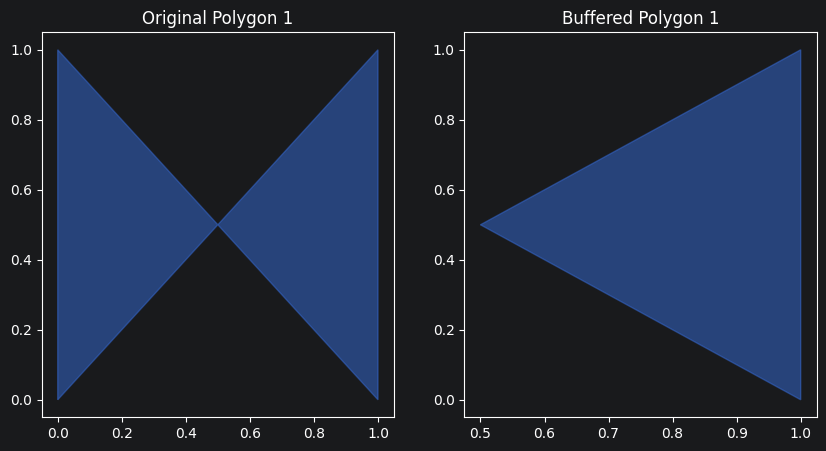

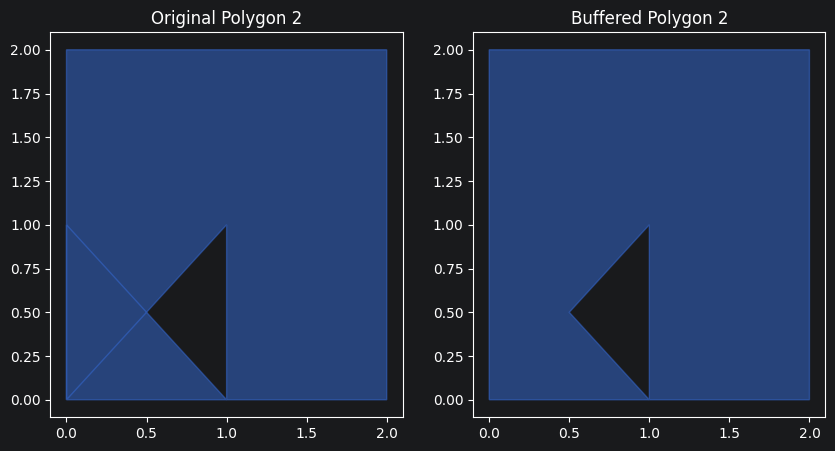

In [26]:
# Plot the original and buffered polygons to visualize the changes
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_polygon(polygon1, ax=ax[0], add_points=False, alpha=0.5)
ax[0].set_title('Original Polygon 1')
plot_polygon(buffered_polygon1, ax=ax[1], add_points=False, alpha=0.5)
ax[1].set_title('Buffered Polygon 1')
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_polygon(polygon2, ax=ax[0], add_points=False, alpha=0.5)
ax[0].set_title('Original Polygon 2')
plot_polygon(buffered_polygon2, ax=ax[1], add_points=False, alpha=0.5)
ax[1].set_title('Buffered Polygon 2')

As you can see, in both cases the polygons are valid, but the shape (mainly in the first case) is not the same as the original polygon. Therefore, this method may not be suitable for all cases, take care when using it.

## 2. Using the `make_valid` method

The `make_valid` method is a more robust way to fix invalid polygons. It attempts to create a valid polygon from an invalid one by removing self-intersections and other issues. When Shapely's `make_valid` fixes a heavily tangled or self-intersecting shape (like the second example), it breaks the shape down into its constituent valid parts. The result is often a `GeometryCollection` containing a heterogeneous mix of valid Polygons, LineStrings, and Points.

Let's try to fix the invalid polygons using the `make_valid` method and check if they are valid.

In [30]:
# Fix the invalid polygons using the make_valid method
valid_polygon1 = make_valid(polygon1)
is_valid = valid_polygon1.is_valid
print("Is the valid polygon 1 valid?", is_valid)
valid_polygon2 = make_valid(polygon2)
is_valid = valid_polygon2.is_valid
print("Is the valid polygon 2 valid?", is_valid)

Is the valid polygon 1 valid? True
Is the valid polygon 2 valid? True


Text(0.5, 1.0, 'Valid Polygon 2')

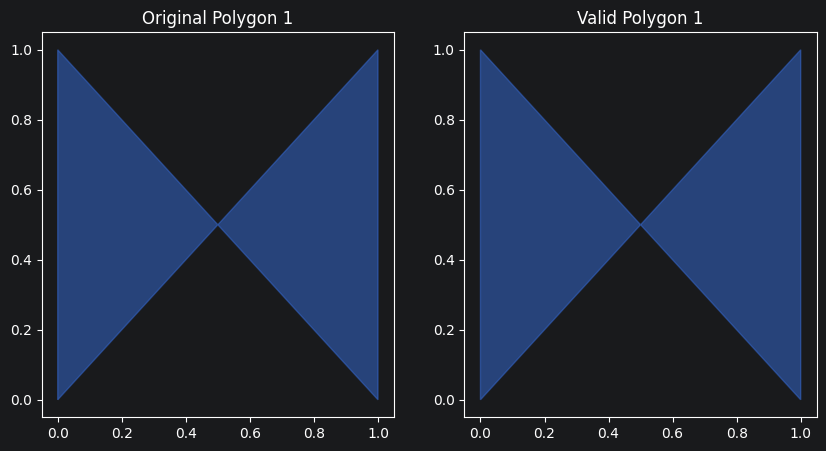

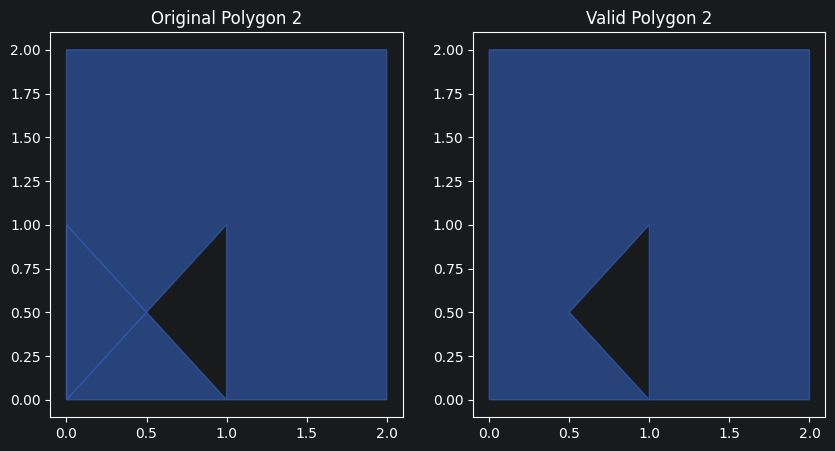

In [35]:
# Plot the valid polygon 1
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_polygon(polygon1, ax=ax[0], add_points=False, alpha=0.5)
ax[0].set_title('Original Polygon 1')
plot_polygon(valid_polygon1, ax=ax[1], add_points=False, alpha=0.5)
ax[1].set_title('Valid Polygon 1')

# 1. Plot Original
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_polygon(polygon2, ax=ax[0], add_points=False, alpha=0.5)
ax[0].set_title('Original Polygon 2')

# 2. Filter the valid geometry to keep only Polygons/MultiPolygons
if valid_polygon2.geom_type == 'GeometryCollection':
    valid_polys = [geom for geom in valid_polygon2.geoms if isinstance(geom, (Polygon, MultiPolygon))]
    plot_shape = MultiPolygon(valid_polys)
else:
    plot_shape = valid_polygon2

# 3. Plot the filtered valid shape
plot_polygon(plot_shape, ax=ax[1], add_points=False, alpha=0.5)
ax[1].set_title('Valid Polygon 2')


For this particular case, the `make_valid` method is the best option to fix invalid polygons. However, it is important to note that this method may not work for all cases, and it may create a new polygon that is not valid. Therefore, it is important to check if the polygon is valid after using this method.

# Test case: Checking events inside the VMM polygon

Another fact to consider is that **_SieveComP_** uses the `shapely` library to check if a point is inside a polygon. The `shapely` library provides a method called `contains` that checks if a point is inside a polygon. In this context, a point is inside a polygon if it is located within the boundaries of the polygon. If a point is not inside a polygon, it can be located outside the boundaries of the polygon or on the boundary of the polygon.

Let's consider a critical case where an event is located very close to the boundary of a polygon. In this case, the event may be considered inside the polygon even though it is not. This can happen due to the precision of the coordinates or the shape of the polygon. Therefore, it is important to check if a point is inside a polygon using different methods and to consider the precision of the coordinates.

The event considered here is from El Playón Santander in 2025-04-04 05:47 UTC. Let's try with 3 different combinations of coordinates:

Is the point case1 inside the polygon? False
Is the point case2 inside the polygon? False
Is the point case3 inside the polygon? True


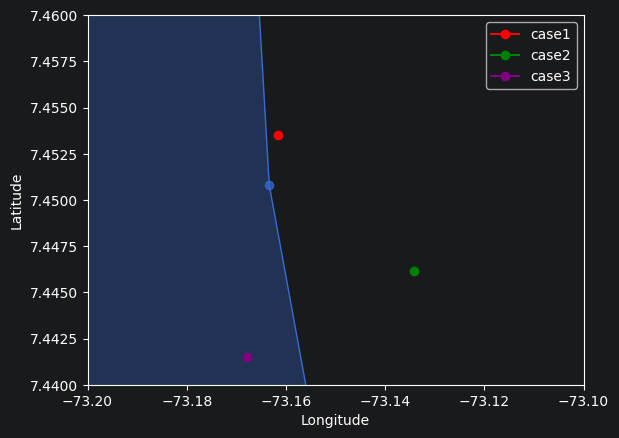

In [37]:
vmm_coords = {'case1': (-73.1615, 7.4535), 'case2': (-73.134167, 7.446167), 'case3': (-73.167833, 7.4415)}
colors = ['red', 'green', 'purple']
polygon = shapely_zone_data['VMM.txt']

fig, ax = plt.subplots()
plot_polygon(polygon, ax=ax, add_points=False)
plot_points(polygon, ax=ax, alpha=0.7)
for case, coords in vmm_coords.items():
    point = Point(coords)
    print(f"Is the point {case} inside the polygon? {polygon.contains(Point(coords))}")
    ax.plot(coords[0], coords[1], label=case, color=colors.pop(0), marker='o')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-73.2, -73.1)
ax.set_ylim(7.44, 7.46)
ax.legend()

As you can notice, **_SieveComP_** can discern if a point is inside a polygon or not, even if the point is very close to the boundary of the polygon. However, it is important to note that this method may not work for all cases, and it may create a new polygon that is not valid. Therefore, it is important to check if the polygon is valid after using this method.